In [12]:
import os
import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns


try:
    titanic_path = kagglehub.dataset_download("adarshgoel/titanic-dataset-with-survival")
    titanic_df = pd.read_csv(os.path.join(titanic_path, 'train.csv'))
    print("Titanic dataset loaded from KaggleHub.")
except Exception as e:
    print(f"Could not load Titanic dataset from KaggleHub: {e}")
    print("Falling back to a commonly available dataset or a URL if possible.")
    try:
        titanic_df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
        print("Titanic dataset loaded from GitHub.")
    except Exception as e_github:
        print(f"Could not load Titanic dataset from GitHub: {e_github}")
        print("Please provide a valid path or method to load the Titanic dataset.")

print("\nInitial Titanic DataFrame head:")
display(titanic_df.head())
print("\nTitanic DataFrame Info:")
titanic_df.info()


Could not load Titanic dataset from KaggleHub: 403 Client Error.

You don't have permission to access resource at URL: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDataset. Please make sure you are authenticated if you are trying to access a private resource or a resource requiring consent.
Falling back to a commonly available dataset or a URL if possible.
Titanic dataset loaded from GitHub.

Initial Titanic DataFrame head:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Titanic DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:

titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)

titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0], inplace=True)

titanic_df.drop('Cabin', axis=1, inplace=True, errors='ignore')

titanic_df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True, errors='ignore')


le = LabelEncoder()
titanic_df['Sex'] = le.fit_transform(titanic_df['Sex'])

titanic_df = pd.get_dummies(titanic_df, columns=['Embarked'], drop_first=True)

print("\nProcessed Titanic DataFrame head:")
display(titanic_df.head())
print("\nProcessed Titanic DataFrame Info:")
titanic_df.info()
print("\nMissing values after preprocessing:")
print(titanic_df.isnull().sum())


Processed Titanic DataFrame head:


/tmp/ipykernel_616/3111572147.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)
/tmp/ipykernel_616/3111572147.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True



Processed Titanic DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(2), float64(2), int64(5)
memory usage: 50.6 KB

Missing values after preprocessing:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64


In [14]:
X_titanic = titanic_df.drop('Survived', axis=1)
y_titanic = titanic_df['Survived']

numerical_cols_titanic = X_titanic.select_dtypes(include=['int64', 'float64']).columns

scaler_titanic = StandardScaler()

X_titanic[numerical_cols_titanic] = scaler_titanic.fit_transform(X_titanic[numerical_cols_titanic])

print("\nFirst 5 rows of features (X_titanic) after scaling:")
display(X_titanic.head())

# Split the data into training and testing sets (80/20 split)
X_train_titanic, X_test_titanic, y_train_titanic, y_test_titanic = train_test_split(
    X_titanic, y_titanic, test_size=0.2, random_state=42
)

print("\nShape of X_train_titanic:", X_train_titanic.shape)
print("Shape of X_test_titanic:", X_test_titanic.shape)
print("Shape of y_train_titanic:", y_train_titanic.shape)
print("Shape of y_test_titanic:", y_test_titanic.shape)


First 5 rows of features (X_titanic) after scaling:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0.827377,0.737695,-0.565736,0.432793,-0.473674,-0.502445,False,True
1,-1.566107,-1.355574,0.663861,0.432793,-0.473674,0.786845,False,False
2,0.827377,-1.355574,-0.258337,-0.474545,-0.473674,-0.488854,False,True
3,-1.566107,-1.355574,0.433312,0.432793,-0.473674,0.420730,False,True
4,0.827377,0.737695,0.433312,-0.474545,-0.473674,-0.486337,False,True



Shape of X_train_titanic: (712, 8)
Shape of X_test_titanic: (179, 8)
Shape of y_train_titanic: (712,)
Shape of y_test_titanic: (179,)


In [15]:
svc_model = SVC(kernel='rbf', random_state=42, probability=True) # probability=True for ROC-AUC
svc_model.fit(X_train_titanic, y_train_titanic)

print("SVC model (RBF kernel) trained successfully.")

SVC model (RBF kernel) trained successfully.



Confusion Matrix:


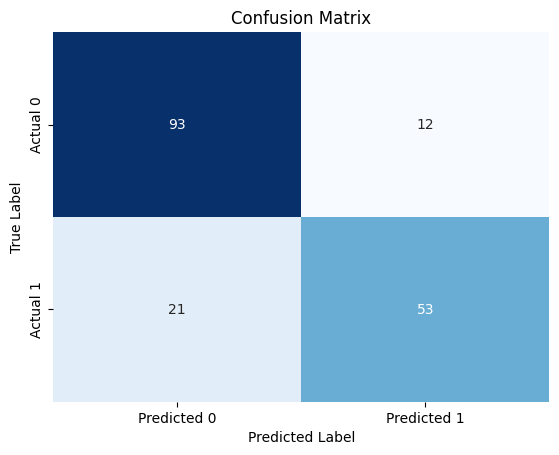


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       105
           1       0.82      0.72      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179

ROC-AUC Score: 0.85


In [16]:
y_pred_titanic = svc_model.predict(X_test_titanic)
y_pred_proba_titanic = svc_model.predict_proba(X_test_titanic)[:, 1]

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_titanic, y_pred_titanic)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_titanic, y_pred_titanic))

roc_auc = roc_auc_score(y_test_titanic, y_pred_proba_titanic)
print(f"ROC-AUC Score: {roc_auc:.2f}")